In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer

## Load the data

In [2]:
df = pd.read_csv("./data/laptop_price_merged_categories.csv")
df.head()

,inches,ram,weight,primary_memory_size,secondary_memory_size,cpu_speed_ghz,company,typename,opsys,primary_memory_type,cpu_manufacturer,screen_resolution,display_type,gpu_manufacturer,gpu_model,has_secondary_memory,cpu_model_reduced,price_euros
0,13.3,8,1.37,128.0,0,2.3,other,ultrabook,other,ssd,intel,other,other,intel,other,no,core i5,1339.69
1,13.3,8,1.34,128.0,0,1.8,other,ultrabook,other,ssd,intel,other,other,intel,other,no,core i5,898.94
2,15.6,8,1.86,256.0,0,2.5,hp,notebook,no os,ssd,intel,1920x1080,full hd,intel,hd graphics 620,no,core i5,575.00
3,15.4,16,1.83,512.0,0,2.7,other,ultrabook,other,ssd,intel,other,other,other,other,no,core i7,2537.45
4,13.3,8,1.37,256.0,0,3.1,other,ultrabook,other,ssd,intel,other,other,intel,other,no,core i5,1803.60


## Check data info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   inches                 1275 non-null   float64
 1   ram                    1275 non-null   int64  
 2   weight                 1275 non-null   float64
 3   primary_memory_size    1274 non-null   float64
 4   secondary_memory_size  1275 non-null   int64  
 5   cpu_speed_ghz          1275 non-null   float64
 6   company                1275 non-null   object 
 7   typename               1275 non-null   object 
 8   opsys                  1275 non-null   object 
 9   primary_memory_type    1275 non-null   object 
 10  cpu_manufacturer       1275 non-null   object 
 11  screen_resolution      1275 non-null   object 
 12  display_type           1275 non-null   object 
 13  gpu_manufacturer       1275 non-null   object 
 14  gpu_model              1275 non-null   object 
 15  has_

## Split the data

In [4]:
# Spit into features and target

num_feats = [
    "ram",
    "weight",
    "primary_memory_size",
    "secondary_memory_size",
    "cpu_speed_ghz",
]
cat_feats = [
    "company",
    "typename",
    "opsys",
    "primary_memory_type",
    "cpu_manufacturer",
    "screen_resolution",
    "display_type",
    "gpu_manufacturer",
    "gpu_model",
    "has_secondary_memory",
    "cpu_model_reduced",
]

X = df.drop("price_euros", axis=1)[num_feats + cat_feats]  # Features
y = df["price_euros"]  # Target / Outcome

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1020, 16)
X_test shape: (255, 16)
y_train shape: (1020,)
y_test shape: (255,)


## Build and Evaluate Baseline Model

In [6]:
base_model = DummyRegressor()
base_model.fit(X_train, y_train)

,strategy,'mean'
,constant,None
,quantile,None


Get model predictions

In [7]:
base_train_pred = base_model.predict(X_train)
base_train_pred[:5]

array([1124.68929412, 1124.68929412, 1124.68929412, 1124.68929412,
       1124.68929412])

Get the training error

In [8]:
base_train_rmse = rmse(y_train, base_train_pred)

print("Base Model Error (Training):", base_train_rmse)

Base Model Error (Training): 699.0872463925497


### Get the Cross Validation Errors

In [9]:
cv_errs = cross_val_score(
    base_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

In [10]:
cv_errs = cv_errs * -1

In [11]:
cv_errs

array([740.37219087, 669.12628298, 631.62158023, 799.60500499,
       645.87454688])

In [12]:
print("Base Model Avg. CV Error:", np.mean(cv_errs))
print("Base Model Std. CV Error:", np.std(cv_errs))

Base Model Avg. CV Error: 697.319921190328
Base Model Std. CV Error: 63.36168569646589


### Evaluate the model on the test set.

In [13]:
# Get test set predictions
base_test_pred = base_model.predict(X_test)

In [14]:
base_test_rmse = rmse(y_test, base_test_pred)

print("Base Model Test Error:", base_test_rmse)

Base Model Test Error: 706.3859524585565


# Build and Evaluate Linear Regression Model

In [15]:
# Define numeric tranformation/preprocessing pipeline
num_preprocessor = make_pipeline(SimpleImputer(), PowerTransformer())

# Define column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_preprocessor, num_feats),
        ("cat_encoder", OneHotEncoder(sparse_output=False), cat_feats),
    ],
    verbose_feature_names_out=False,
)

In [16]:
# Instatiate model
lr_model = LinearRegression()

# Use TranformedTargedRegressor for automated tranform and inverse transform of target
regressor = TransformedTargetRegressor(lr_model, transformer=PowerTransformer())

# Define pipeline
lr_pipeline = make_pipeline(preprocessor, regressor)
lr_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


Get train predictions

In [17]:
lr_train_pred = lr_pipeline.predict(X_train)
lr_train_pred[:5]

array([1283.38072261, 1892.46638133, 1086.87657258,  786.45314878,
        613.05290406])

Get the training error

In [18]:
lr_train_rmse = rmse(y_train, lr_train_pred)

print("LR Model Error (Training):", lr_train_rmse)

LR Model Error (Training): 363.61224610003364


### Get the Cross Validation Errors

In [19]:
cv_errs = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
) * -1

In [20]:
cv_errs

array([383.46454551, 337.49458395, 319.2261222 , 457.00921984,
       356.09011994])

In [21]:
print("LR Model Avg. CV Error:", np.mean(cv_errs))
print("LR Model Std. CV Error:", np.std(cv_errs))

LR Model Avg. CV Error: 370.65691828945074
LR Model Std. CV Error: 48.120295338384594


### Evaluate the model on the test set.

In [22]:
# Get test set predictions
lr_test_pred = lr_pipeline.predict(X_test)

In [23]:
lr_test_rmse = rmse(y_test, lr_test_pred)

print("LR Model Test Error:", lr_test_rmse)

LR Model Test Error: 373.92905873872445


In [24]:
print("LR Model Error (Training):", lr_train_rmse)
print("LR Model Avg. CV Error:", np.mean(cv_errs))
print("LR Model Std. CV Error:", np.std(cv_errs))
print("LR Model Test Error:", lr_test_rmse)

LR Model Error (Training): 363.61224610003364
LR Model Avg. CV Error: 370.65691828945074
LR Model Std. CV Error: 48.120295338384594
LR Model Test Error: 373.92905873872445


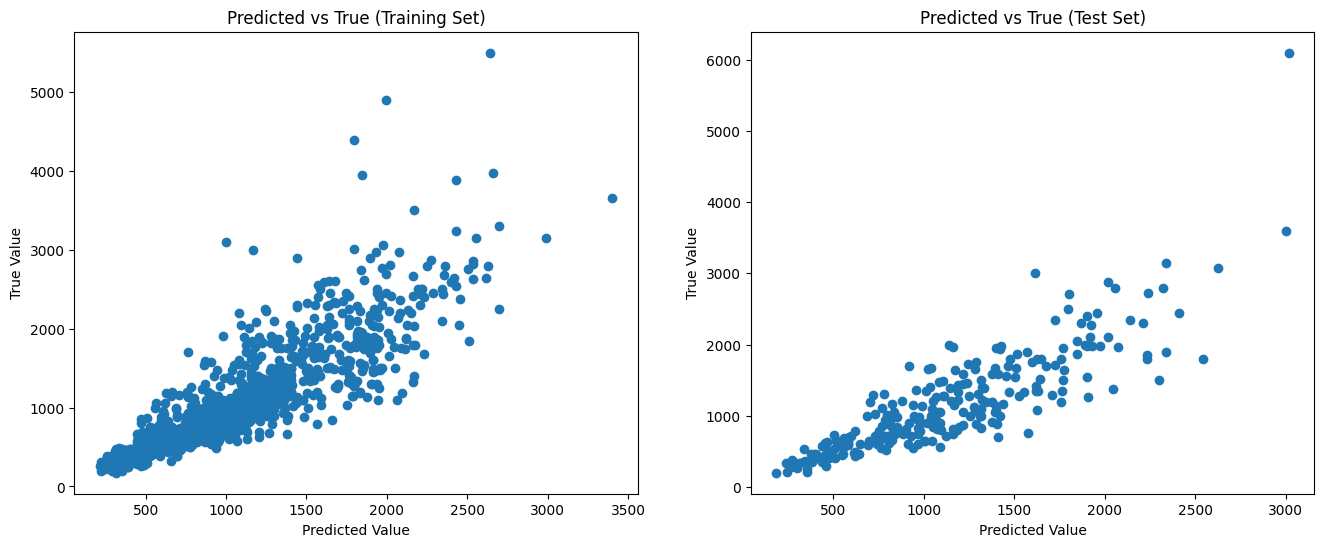

In [25]:
# Visualize predicted and actual values

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(lr_train_pred, y_train)
ax2.scatter(lr_test_pred, y_test)

ax1.set_xlabel("Predicted Value")
ax1.set_ylabel("True Value")
ax1.set_title("Predicted vs True (Training Set)")

ax2.set_xlabel("Predicted Value")
ax2.set_ylabel("True Value")
ax2.set_title("Predicted vs True (Test Set)");

### Inspect model Parameters

In [26]:
# Check model parameters

intercept = (
    lr_pipeline[-1].regressor_.intercept_
)  # or lr_pipeline.named_steps["transformedtargetregressor"].regressor_.intercept_
coefs_series = pd.Series(
    lr_pipeline[-1].regressor_.coef_, index=preprocessor.get_feature_names_out()
)

# Print the coefficients
print(f"Intercept: {intercept:.2f}")
print(f"\nCoefficients: \n{coefs_series.round(2)}")

Intercept: -14.75

Coefficients: 
ram                             0.28
weight                          0.02
primary_memory_size             0.25
secondary_memory_size          15.88
cpu_speed_ghz                   0.12
company_acer                   -0.23
company_asus                   -0.08
company_dell                    0.10
company_hp                      0.16
company_lenovo                 -0.01
company_other                   0.06
typename_gaming                -0.05
typename_notebook              -0.27
typename_other                  0.15
typename_ultrabook              0.17
opsys_linux                    -0.14
opsys_no os                    -0.37
opsys_other                     0.37
opsys_windows 10                0.13
primary_memory_type_other      -0.32
primary_memory_type_ssd         0.32
cpu_manufacturer_intel          0.09
cpu_manufacturer_other         -0.09
screen_resolution_1366x768     -0.11
screen_resolution_1920x1080    -0.10
screen_resolution_other         0.21
disp

<Axes: >

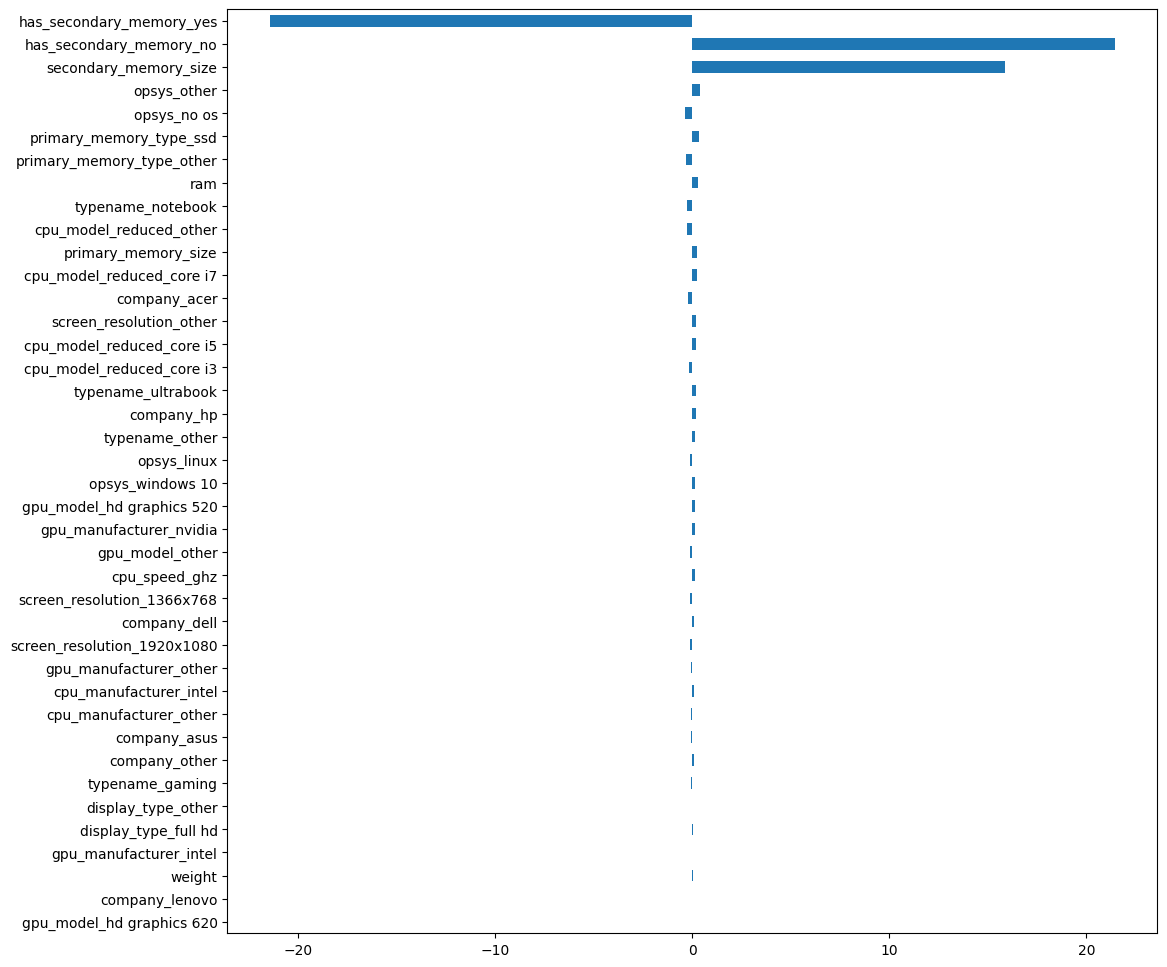

In [27]:
coefs_series.sort_values(key=abs).plot(kind="barh", figsize=(12, 12))

# Build and Evaluate Decision Tree Model

In [28]:
from sklearn.tree import DecisionTreeRegressor

In [29]:
# Spit the data

num_feats = df.select_dtypes("number").columns.drop("price_euros").to_list()
cat_feats = df.select_dtypes("object").columns.to_list()

X = df.drop("price_euros", axis=1)  # Features
y = df["price_euros"]  # Target / Outcome

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
# Define column transformer
transformer = ColumnTransformer(
    transformers = [
        ("imputer", SimpleImputer(), num_feats),
        ("encoder", OneHotEncoder(sparse_output=False), cat_feats)
    ],
    verbose_feature_names_out=False
)

In [31]:
# Instatiate model
dt_model = DecisionTreeRegressor(random_state=42)

# Define pipeline
dt_pipeline = make_pipeline(transformer, dt_model)
dt_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('imputer', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [32]:
# Check tree depth

dt_pipeline[-1].get_depth()

27

### Find optimal tree depth

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
dt_pipeline.steps

[('columntransformer',
  ColumnTransformer(transformers=[('imputer', SimpleImputer(),
                                   ['inches', 'ram', 'weight',
                                    'primary_memory_size',
                                    'secondary_memory_size', 'cpu_speed_ghz']),
                                  ('encoder', OneHotEncoder(sparse_output=False),
                                   ['company', 'typename', 'opsys',
                                    'primary_memory_type', 'cpu_manufacturer',
                                    'screen_resolution', 'display_type',
                                    'gpu_manufacturer', 'gpu_model',
                                    'has_secondary_memory',
                                    'cpu_model_reduced'])],
                    verbose_feature_names_out=False)),
 ('decisiontreeregressor', DecisionTreeRegressor(random_state=42))]

In [35]:
grid_search = GridSearchCV(
    dt_pipeline,
    param_grid={
        "decisiontreeregressor__max_depth": range(1, 28)
    },  # param grid key for models in pipeline is always combined with pipeline step name 
        # and model parameter seperated by double under score
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

grid_search_result = pd.DataFrame(grid_search.cv_results_)
grid_search_result.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeregressor__max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.106663,0.040051,0.050244,0.018327,1,{'decisiontreeregressor__max_depth': 1},-569.372176,-546.314093,-514.839080,-651.531794,...,-557.817081,51.913195,27,-554.548287,-560.212797,-568.137886,-532.342446,-569.397844,-556.927852,13.431760
1,0.080476,0.040778,0.034081,0.020644,2,{'decisiontreeregressor__max_depth': 2},-447.149337,-445.557734,-426.590586,-535.232559,...,-460.256112,38.275503,26,-457.516800,-457.670017,-463.578776,-435.045273,-458.292859,-454.420745,9.943994
2,0.061561,0.039875,0.024158,0.018230,3,{'decisiontreeregressor__max_depth': 3},-386.935923,-424.167518,-383.041721,-508.879955,...,-430.959132,46.443550,25,-401.683330,-397.141878,-404.319280,-381.282742,-399.640191,-396.813484,8.116088
3,0.049070,0.014893,0.026157,0.015958,4,{'decisiontreeregressor__max_depth': 4},-379.452092,-430.385617,-363.356752,-482.841055,...,-415.859487,42.034201,24,-354.300047,-356.047380,-359.477991,-340.341653,-364.326844,-354.898783,8.042951
4,0.059977,0.034388,0.026391,0.015612,5,{'decisiontreeregressor__max_depth': 5},-365.691977,-426.094592,-359.713115,-482.852903,...,-407.894095,44.855800,23,-312.381446,-321.539606,-322.642983,-298.330121,-319.546771,-314.888186,9.017028


Plot the validation curve of the model

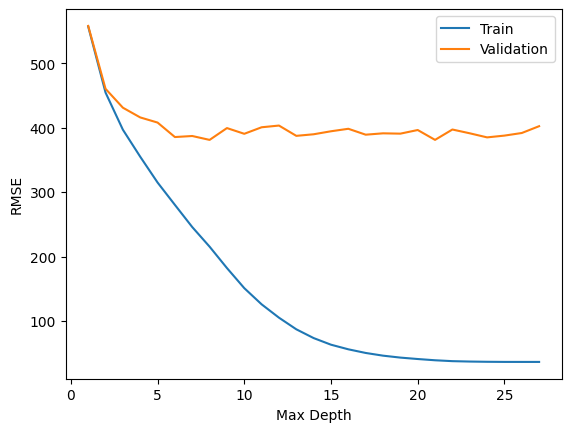

In [36]:
plt.plot(
    grid_search_result["param_decisiontreeregressor__max_depth"],
    grid_search_result["mean_train_score"].mul(-1),
    label="Train"
)
plt.plot(
    grid_search_result["param_decisiontreeregressor__max_depth"],
    grid_search_result["mean_test_score"].mul(-1),
    label="Validation"
)
plt.legend()
plt.xlabel("Max Depth")
plt.ylabel("RMSE");

In [37]:
# Check best parameter
grid_search.best_params_

{'decisiontreeregressor__max_depth': 8}

### Retrain model with the best parameter

In [38]:
# Instatiate model
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)

# Define pipeline
dt_pipeline = make_pipeline(transformer, dt_model)
dt_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('imputer', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


Get train predictions

In [39]:
dt_train_pred = dt_pipeline.predict(X_train)
dt_train_pred[:5]

array([ 901.04052632, 1800.72783133,  675.32292683,  764.84652174,
        465.84324324])

Get the training error

In [40]:
dt_train_rmse = rmse(y_train, dt_train_pred)

print("DT Model Error (Training):", dt_train_rmse)

DT Model Error (Training): 223.81104924713276


### Get the Cross Validation Errors

In [41]:
cv_errs = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
) * -1

In [42]:
cv_errs

array([360.81655808, 385.91853992, 354.87849177, 406.17313992,
       397.23927617])

In [43]:
print("DT Model Avg. CV Error:", np.mean(cv_errs))
print("DT Model Std. CV Error:", np.std(cv_errs))

DT Model Avg. CV Error: 381.00520117139223
DT Model Std. CV Error: 20.056407872647096


### Evaluate the model on the test set.

In [44]:
# Get test set predictions
dt_test_pred = dt_pipeline.predict(X_test)

In [45]:
dt_test_rmse = rmse(y_test, dt_test_pred)

print("dt Model Test Error:", dt_test_rmse)

dt Model Test Error: 379.9021587258152


# Plot Predicted vs True Values

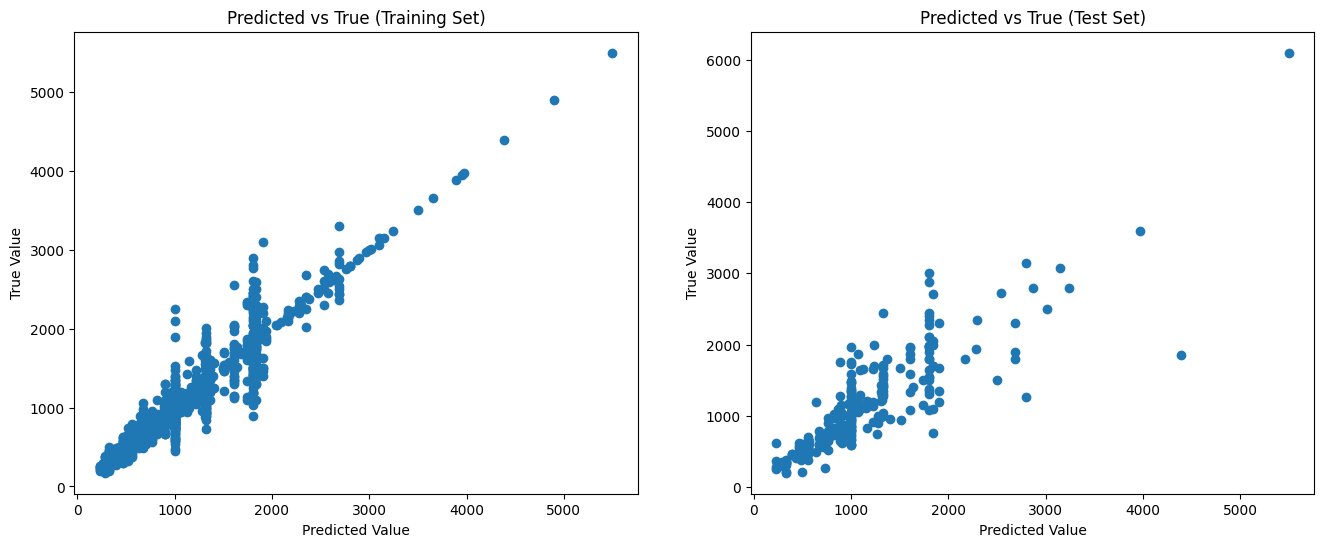

In [46]:
# Visualize predicted and actual values

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(dt_train_pred, y_train)
ax2.scatter(dt_test_pred, y_test)

ax1.set_xlabel("Predicted Value")
ax1.set_ylabel("True Value")
ax1.set_title("Predicted vs True (Training Set)")

ax2.set_xlabel("Predicted Value")
ax2.set_ylabel("True Value")
ax2.set_title("Predicted vs True (Test Set)");

### Inspect model Parameters

In [47]:
# Check model feature importance

feat_importance = pd.Series(
    dt_pipeline[-1].feature_importances_, index=transformer.get_feature_names_out()
)

print(f"Feature Importances: \n{feat_importance.round(2)}")

Feature Importances: 
inches                         0.03
ram                            0.64
weight                         0.06
primary_memory_size            0.03
secondary_memory_size          0.00
cpu_speed_ghz                  0.05
company_acer                   0.00
company_asus                   0.00
company_dell                   0.00
company_hp                     0.01
company_lenovo                 0.00
company_other                  0.00
typename_gaming                0.01
typename_notebook              0.06
typename_other                 0.00
typename_ultrabook             0.00
opsys_linux                    0.00
opsys_no os                    0.00
opsys_other                    0.02
opsys_windows 10               0.00
primary_memory_type_other      0.01
primary_memory_type_ssd        0.00
cpu_manufacturer_intel         0.00
cpu_manufacturer_other         0.00
screen_resolution_1366x768     0.00
screen_resolution_1920x1080    0.03
screen_resolution_other        0.00
displa

<Axes: >

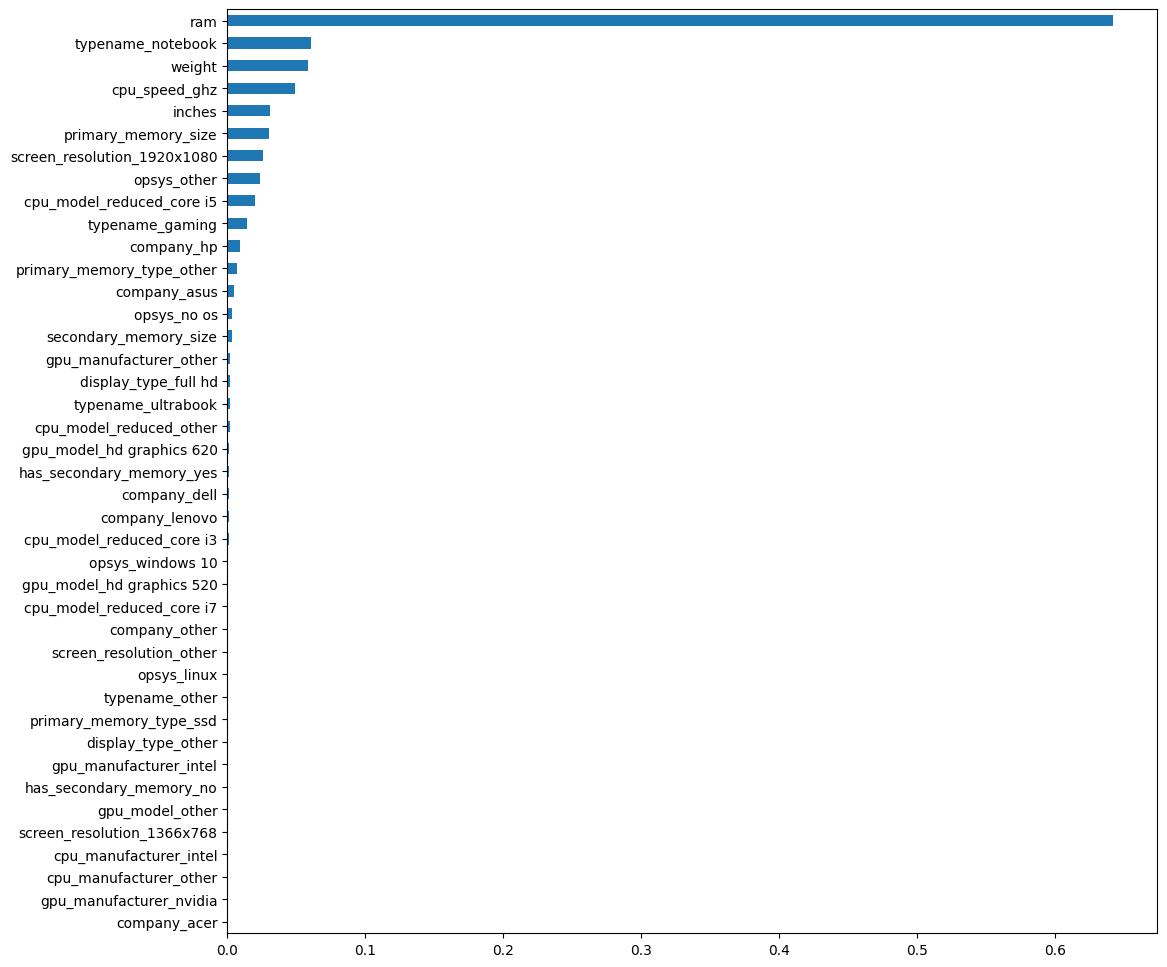

In [48]:
# Plot Feature Importance

feat_importance.sort_values().plot(kind="barh", figsize=(12, 12))

# Build and Evaluate Random Forest Model

In [49]:
from sklearn.ensemble import RandomForestRegressor

In [50]:
# Instantiate model
rf_model = RandomForestRegressor(max_depth=8, random_state=42)

# Define pipeline
rf_pipeline = make_pipeline(transformer, rf_model)
rf_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('imputer', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


Get train predictions

In [51]:
rf_train_pred = rf_pipeline.predict(X_train)
rf_train_pred[:5]

array([1138.28409993, 2172.04400018,  713.17283683,  764.2515334 ,
        494.50689474])

Get the training error

In [52]:
rf_train_rmse = rmse(y_train, rf_train_pred)

print("RF Model Error (Training):", rf_train_rmse)

RF Model Error (Training): 199.38495839375707


### Get the Cross Validation Errors

In [53]:
cv_errs = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
) * -1

In [54]:
cv_errs

array([302.60324053, 288.00845471, 299.26843095, 401.32304566,
       306.35782806])

In [55]:
print("RF Model Avg. CV Error:", np.mean(cv_errs))
print("RF Model Std. CV Error:", np.std(cv_errs))

RF Model Avg. CV Error: 319.5121999819463
RF Model Std. CV Error: 41.36244923214584


### Evaluate the model on the test set.

In [56]:
# Get test set predictions
rf_test_pred = rf_pipeline.predict(X_test)

In [57]:
rf_test_rmse = rmse(y_test, rf_test_pred)

print("RF Model Test Error:", rf_test_rmse)

RF Model Test Error: 285.160956892386


# Plot Predicted vs True Values

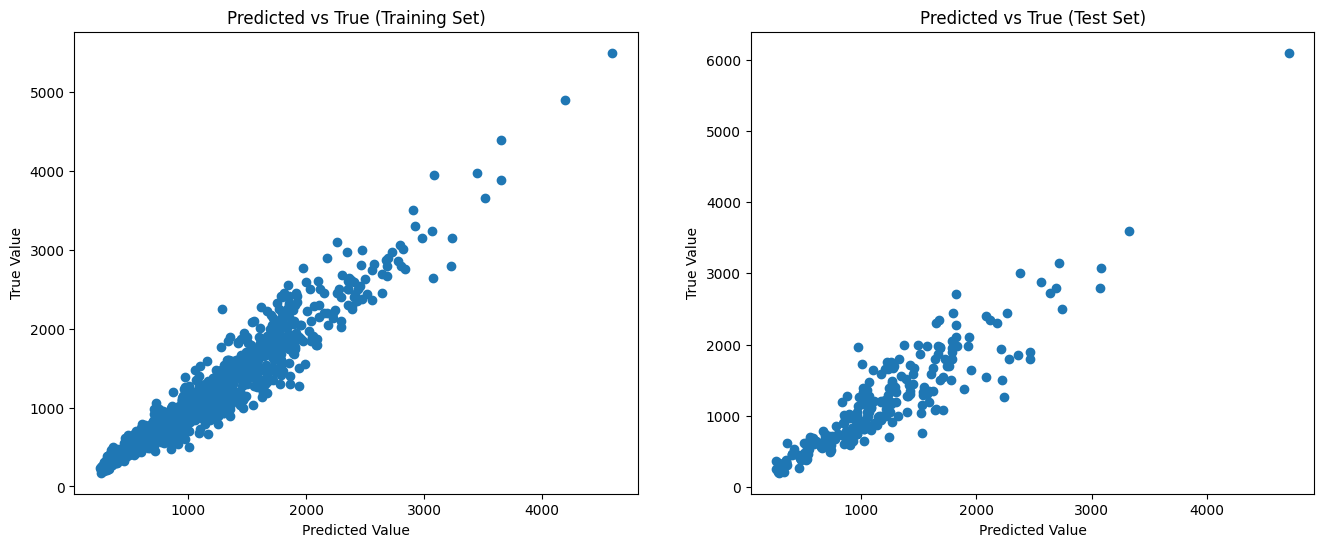

In [58]:
# Visualize predicted and actual values

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(rf_train_pred, y_train)
ax2.scatter(rf_test_pred, y_test)

ax1.set_xlabel("Predicted Value")
ax1.set_ylabel("True Value")
ax1.set_title("Predicted vs True (Training Set)")

ax2.set_xlabel("Predicted Value")
ax2.set_ylabel("True Value")
ax2.set_title("Predicted vs True (Test Set)");

### Inspect model Parameters

In [59]:
# Check model feature importance

feat_importance = pd.Series(
    rf_pipeline[-1].feature_importances_, index=transformer.get_feature_names_out()
)

print(f"Feature Importances: \n{feat_importance.round(2)}")

Feature Importances: 
inches                         0.02
ram                            0.56
weight                         0.09
primary_memory_size            0.03
secondary_memory_size          0.00
cpu_speed_ghz                  0.05
company_acer                   0.00
company_asus                   0.01
company_dell                   0.00
company_hp                     0.01
company_lenovo                 0.00
company_other                  0.00
typename_gaming                0.01
typename_notebook              0.07
typename_other                 0.00
typename_ultrabook             0.00
opsys_linux                    0.00
opsys_no os                    0.00
opsys_other                    0.01
opsys_windows 10               0.00
primary_memory_type_other      0.00
primary_memory_type_ssd        0.00
cpu_manufacturer_intel         0.00
cpu_manufacturer_other         0.00
screen_resolution_1366x768     0.00
screen_resolution_1920x1080    0.00
screen_resolution_other        0.01
displa

<Axes: >

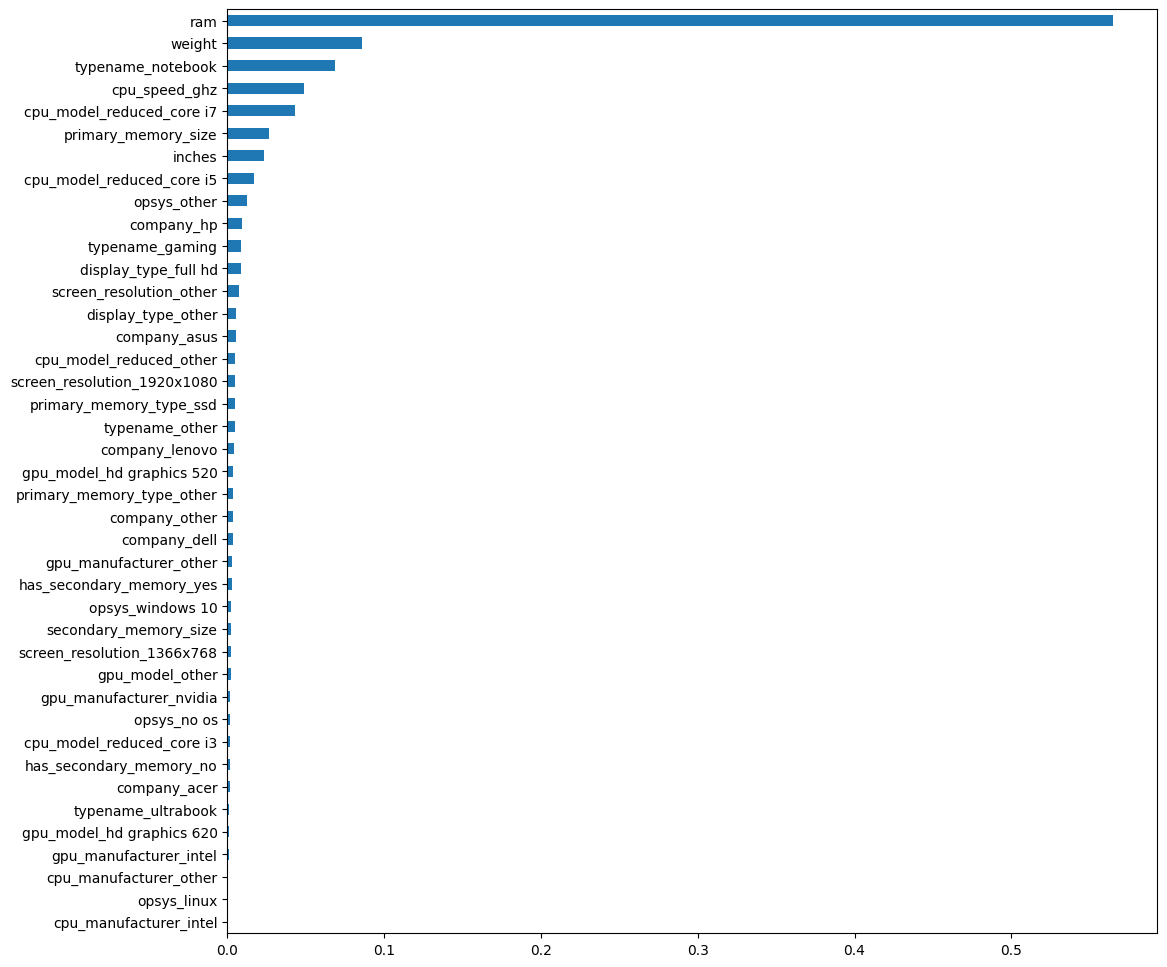

In [60]:
# Plot Feature Importance

feat_importance.sort_values().plot(kind="barh", figsize=(12, 12))

# Build and Evaluate Gradient Boosting Model

In [61]:
from sklearn.ensemble import GradientBoostingRegressor

In [62]:
# Instatiate model
gb_model = GradientBoostingRegressor(max_depth=8, random_state=42)

# Define pipeline
gb_pipeline = make_pipeline(transformer, gb_model)

Find optimal learning rate and number of estimator for GB model

In [63]:
grid_search = GridSearchCV(
    gb_pipeline,
    param_grid={
        "gradientboostingregressor__learning_rate": [0.02, 0.04, 0.06, 0.08, 0.1],
        "gradientboostingregressor__n_estimators": [20, 40, 60, 80, 100]
    },
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

grid_search_result = pd.DataFrame(grid_search.cv_results_)
grid_search_result.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gradientboostingregressor__learning_rate,param_gradientboostingregressor__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.292864,0.078144,0.023228,0.007996,0.02,20,{'gradientboostingregressor__learning_rate': 0...,-540.491047,-481.691344,-462.738430,...,-522.990941,61.656829,25,-482.622899,-496.340946,-503.512564,-471.031694,-495.922207,-489.886062,11.593298
1,0.490072,0.169862,0.020694,0.008808,0.02,40,{'gradientboostingregressor__learning_rate': 0...,-427.062289,-382.637659,-373.605695,...,-424.988157,58.080449,24,-349.065827,-358.832800,-366.554556,-340.059239,-354.510770,-353.804638,8.941295
2,0.628616,0.183601,0.020353,0.009563,0.02,60,{'gradientboostingregressor__learning_rate': 0...,-357.000347,-340.325534,-326.957086,...,-371.749612,52.632865,22,-258.103714,-267.447092,-272.610643,-254.197271,-260.173919,-262.506528,6.638854
3,0.806598,0.319271,0.021534,0.007041,0.02,80,{'gradientboostingregressor__learning_rate': 0...,-321.235496,-327.094611,-303.234336,...,-343.750780,44.557456,19,-197.859449,-207.131226,-208.713793,-196.932071,-197.824280,-201.692164,5.122409
4,0.861809,0.154733,0.016801,0.002102,0.02,100,{'gradientboostingregressor__learning_rate': 0...,-304.787573,-329.034239,-294.529933,...,-331.058136,39.182134,17,-157.754497,-166.982633,-167.691845,-159.940035,-157.591546,-161.992111,4.448048


In [64]:
grid_search.best_params_

{'gradientboostingregressor__learning_rate': 0.1,
 'gradientboostingregressor__n_estimators': 80}

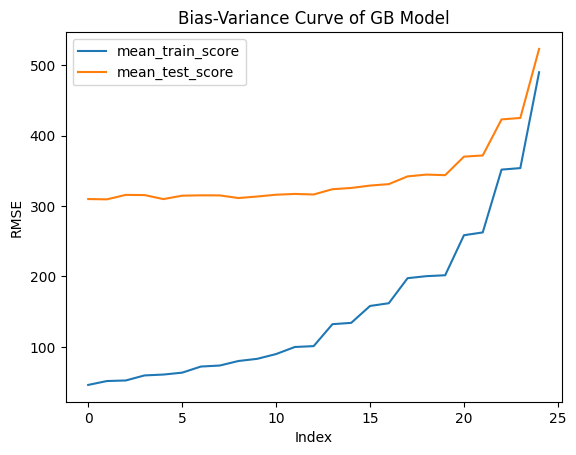

In [65]:
# Plot the bias-variance curve of the gb parameters

grid_search_result[["mean_train_score", "mean_test_score"]].mul(-1).sort_values(
    "mean_train_score"
).reset_index(drop=True).plot()
plt.title("Bias-Variance Curve of GB Model")
plt.xlabel("Index")
plt.ylabel("RMSE");

In [66]:
# Refit gb model with the best parameter

# Instatiate model
gb_model = GradientBoostingRegressor(
    max_depth=8, n_estimators=80, learning_rate=0.1, random_state=42
)

# Define pipeline
gb_pipeline = make_pipeline(transformer, gb_model)
gb_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('gradientboostingregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('imputer', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


Get train predictions

In [67]:
gb_train_pred = gb_pipeline.predict(X_train)
gb_train_pred[:5]

array([ 814.87472102, 2835.1017787 ,  839.87600334,  619.1947811 ,
        439.41922067])

Get the training error

In [68]:
gb_train_rmse = rmse(y_train, gb_train_pred)

print("GB Model Error (Training):", gb_train_rmse)

GB Model Error (Training): 60.46953871651871


### Get the Cross Validation Errors

In [69]:
cv_errs = cross_val_score(
    gb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
) * -1

In [70]:
cv_errs

array([278.68707553, 330.69137272, 283.85182151, 356.32685003,
       297.74354539])

In [71]:
print("GB Model Avg. CV Error:", np.mean(cv_errs))
print("GB Model Std. CV Error:", np.std(cv_errs))

GB Model Avg. CV Error: 309.460133034867
GB Model Std. CV Error: 29.621950693251584


### Evaluate the model on the test set.

In [72]:
# Get test set predictions
gb_test_pred = gb_pipeline.predict(X_test)

In [77]:
gb_test_rmse = rmse(y_test, gb_test_pred)

print("GB Model Test Error:", gb_test_rmse)

GB Model Test Error: 297.3578915470083


# Plot Predicted vs True Values

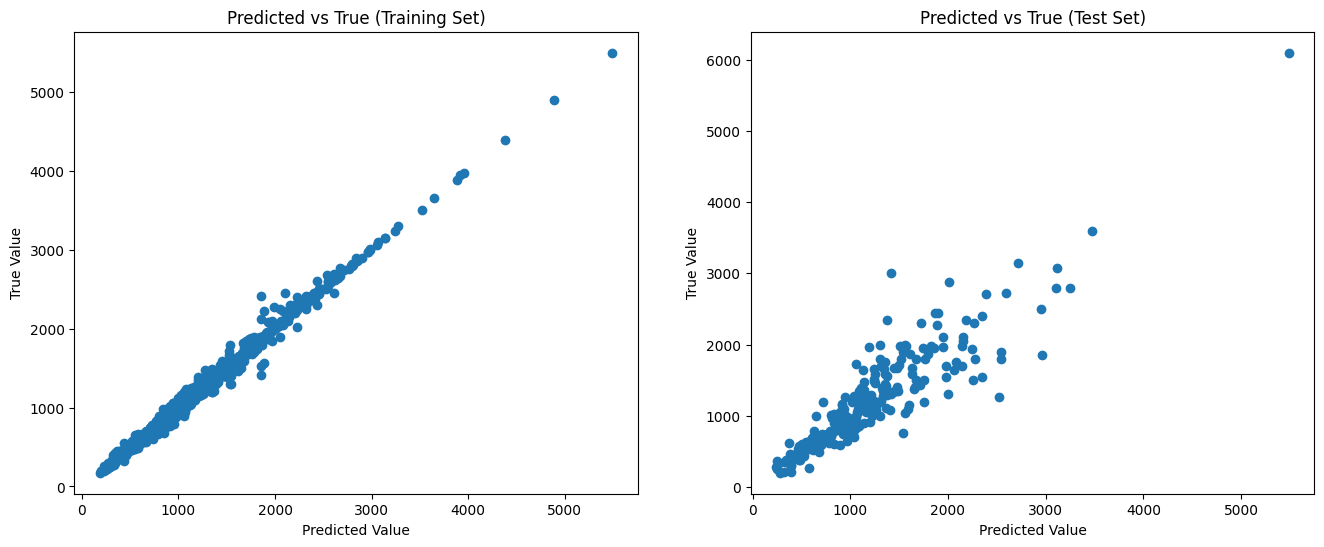

In [74]:
# Visualize predicted and actual values

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(gb_train_pred, y_train)
ax2.scatter(gb_test_pred, y_test)

ax1.set_xlabel("Predicted Value")
ax1.set_ylabel("True Value")
ax1.set_title("Predicted vs True (Training Set)")

ax2.set_xlabel("Predicted Value")
ax2.set_ylabel("True Value")
ax2.set_title("Predicted vs True (Test Set)");

### Inspect model Parameters

In [75]:
# Check model feature importance

feat_importance = pd.Series(
    gb_pipeline[-1].feature_importances_, index=transformer.get_feature_names_out()
)

print(f"Feature Importances: \n{feat_importance.round(2)}")

Feature Importances: 
inches                         0.02
ram                            0.55
weight                         0.09
primary_memory_size            0.03
secondary_memory_size          0.00
cpu_speed_ghz                  0.05
company_acer                   0.00
company_asus                   0.01
company_dell                   0.01
company_hp                     0.01
company_lenovo                 0.00
company_other                  0.00
typename_gaming                0.01
typename_notebook              0.05
typename_other                 0.00
typename_ultrabook             0.00
opsys_linux                    0.00
opsys_no os                    0.00
opsys_other                    0.02
opsys_windows 10               0.00
primary_memory_type_other      0.00
primary_memory_type_ssd        0.00
cpu_manufacturer_intel         0.00
cpu_manufacturer_other         0.00
screen_resolution_1366x768     0.00
screen_resolution_1920x1080    0.01
screen_resolution_other        0.00
displa

<Axes: >

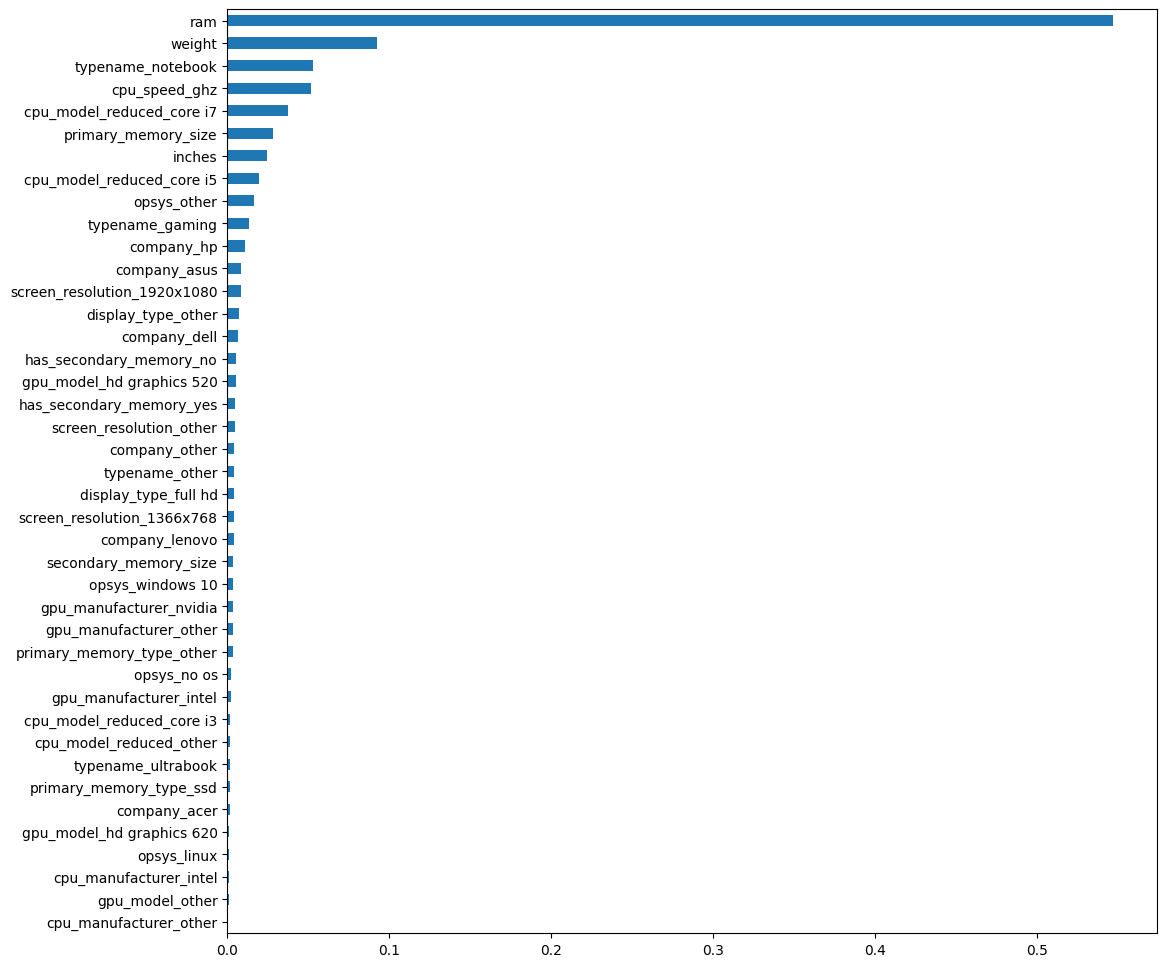

In [76]:
# Plot Feature Importance

feat_importance.sort_values().plot(kind="barh", figsize=(12, 12))

## Add KMeans Features to Random Forest Model

In [119]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion
from sklearn import set_config

In [120]:
set_config(transform_output="pandas")

In [89]:
# By default kmeans transform method generates cluster distances for each data point.
# We can modify it to generate cluster labels instead


class CustomKMeans(KMeans):
    def get_feature_names_out(self, input_features=None):
        feat_names = [f"distance_{i}" for i in range(self.n_clusters)] + [
            "cluster_label"
        ]
        return feat_names

    def _transform(self, X):
        distances = super()._transform(X)
        labels = self.predict(X).reshape(-1, 1)
        feats = np.hstack((distances, labels))
        return feats

    def transform(self, X):
        return self._transform(X)

In [121]:
# Create kmeans pipeline

kmean_pipe = make_pipeline(
    transformer,
    StandardScaler(),
    CustomKMeans(8, random_state=42),
    # KMeans(8, random_state=42) # Uncomment to use normal KMeans.transform() method
)

In [122]:
# Create feature union to combine kmeans features with normal features
feat_union = FeatureUnion(
    [
        ("base_feat", transformer),
        ("kmeans_feat", kmean_pipe),
    ],
    verbose_feature_names_out=False
)

# Create OneHot encoder for kmeans labels
kmeans_label_encoder = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [-1])],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

In [123]:
# Instantiate model
rf_model = RandomForestRegressor(max_depth=8, random_state=42)

# Define pipelineegressor(max_depth=8)
rf_pipeline = make_pipeline(feat_union, kmeans_label_encoder, rf_model)
rf_pipeline.fit(X_train, y_train)

,steps,"[('featureunion', ...), ('columntransformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('base_feat', ...), ('kmeans_feat', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,missing_values,nan
,strategy,'mean'


Get train predictions

In [124]:
rf_train_pred = rf_pipeline.predict(X_train)
rf_train_pred[:5]

array([1077.52926404, 2357.19402669,  775.25815157,  710.40712018,
        486.34706818])

Get the training error

In [125]:
rf_train_rmse = rmse(y_train, rf_train_pred)

print("RF Model Error (Training):", rf_train_rmse)

RF Model Error (Training): 185.3871975708756


### Get the Cross Validation Errors

In [126]:
cv_errs = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
) * -1

In [127]:
cv_errs

array([313.68090275, 284.46575275, 296.04782727, 417.21383991,
       330.37878162])

In [128]:
print("RF Model Avg. CV Error:", np.mean(cv_errs))
print("RF Model Std. CV Error:", np.std(cv_errs))

RF Model Avg. CV Error: 328.35742085998686
RF Model Std. CV Error: 47.08574658657886


### Evaluate the model on the test set.

In [129]:
# Get test set predictions
rf_test_pred = rf_pipeline.predict(X_test)

In [130]:
rf_test_rmse = rmse(y_test, rf_test_pred)

print("RF Model Test Error:", rf_test_rmse)

RF Model Test Error: 293.3946210033977


### Plot feature importance

<Axes: >

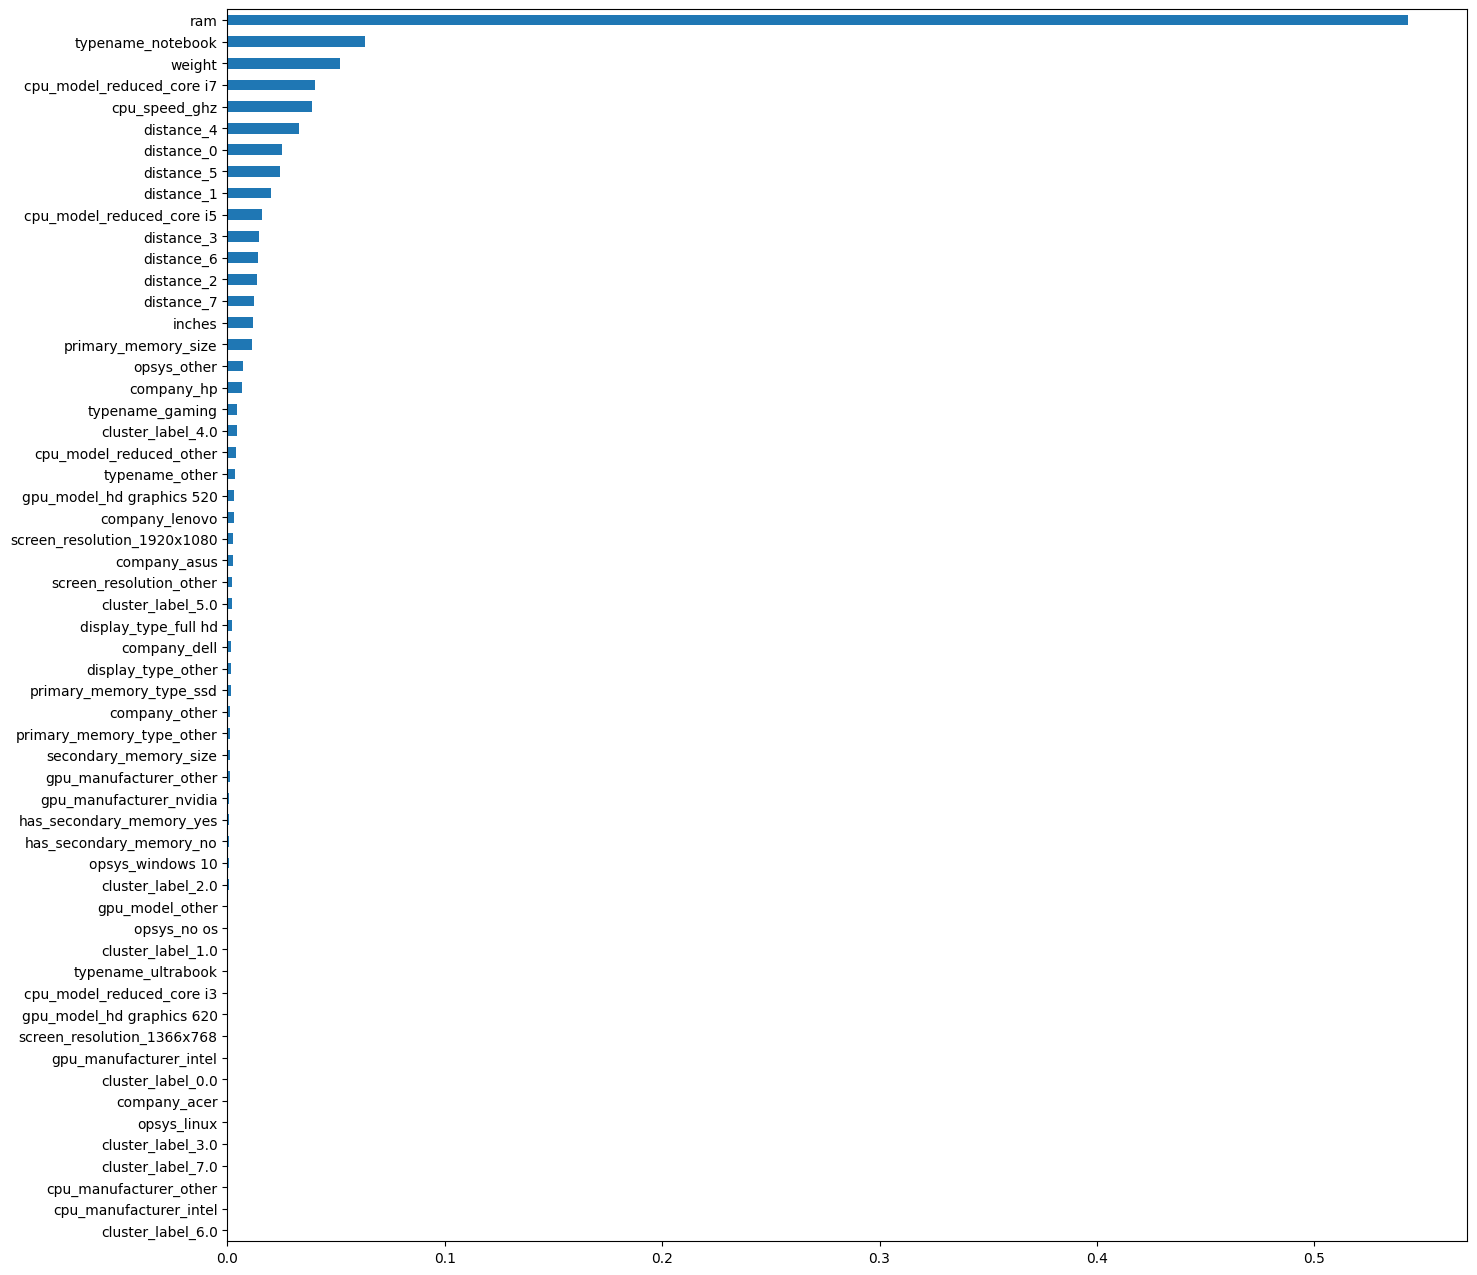

In [135]:
feat_importance = pd.Series(
    rf_pipeline[-1].feature_importances_, index=rf_pipeline[-2].get_feature_names_out()
).sort_values()
feat_importance.plot(kind="barh", figsize=(16, 16))

### Evaluate the model when OrdinalEncoder is used for categorical variables

In [137]:
from sklearn.preprocessing import OrdinalEncoder

In [138]:
# Define column transformer
transformer_2 = ColumnTransformer(
    transformers = [
        ("imputer", SimpleImputer(), num_feats),
        ("encoder", OrdinalEncoder(), cat_feats)
    ],
    verbose_feature_names_out=False
)

In [139]:
# Create feature union to combine kmeans features with normal features
feat_union = FeatureUnion(
    [
        ("base_feat", transformer_2),
        ("kmeans_feat", kmean_pipe),
    ],
    verbose_feature_names_out=False
)

In [141]:
# Instantiate model
rf_model = RandomForestRegressor(max_depth=8, random_state=42)

# Define pipelineegressor(max_depth=8)
rf_pipeline = make_pipeline(feat_union, rf_model)
rf_pipeline.fit(X_train, y_train)

,steps,"[('featureunion', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('base_feat', ...), ('kmeans_feat', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,missing_values,nan
,strategy,'mean'


Get train predictions

In [142]:
rf_train_pred = rf_pipeline.predict(X_train)
rf_train_pred[:5]

array([ 956.06394215, 2343.60117609,  754.290371  ,  709.27635743,
        476.78017263])

Get the training error

In [143]:
rf_train_rmse = rmse(y_train, rf_train_pred)

print("RF Model Error (Training):", rf_train_rmse)

RF Model Error (Training): 190.54714996936792


### Get the Cross Validation Errors

In [144]:
cv_errs = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
) * -1

In [145]:
cv_errs

array([313.6388198 , 286.02595181, 298.49255421, 421.82847566,
       330.03677413])

In [146]:
print("RF Model Avg. CV Error:", np.mean(cv_errs))
print("RF Model Std. CV Error:", np.std(cv_errs))

RF Model Avg. CV Error: 330.00451512271195
RF Model Std. CV Error: 48.22156045367767


### Evaluate the model on the test set.

In [147]:
# Get test set predictions
rf_test_pred = rf_pipeline.predict(X_test)

In [148]:
rf_test_rmse = rmse(y_test, rf_test_pred)

print("RF Model Test Error:", rf_test_rmse)

RF Model Test Error: 315.64723705941935


### Plot feature importance

<Axes: >

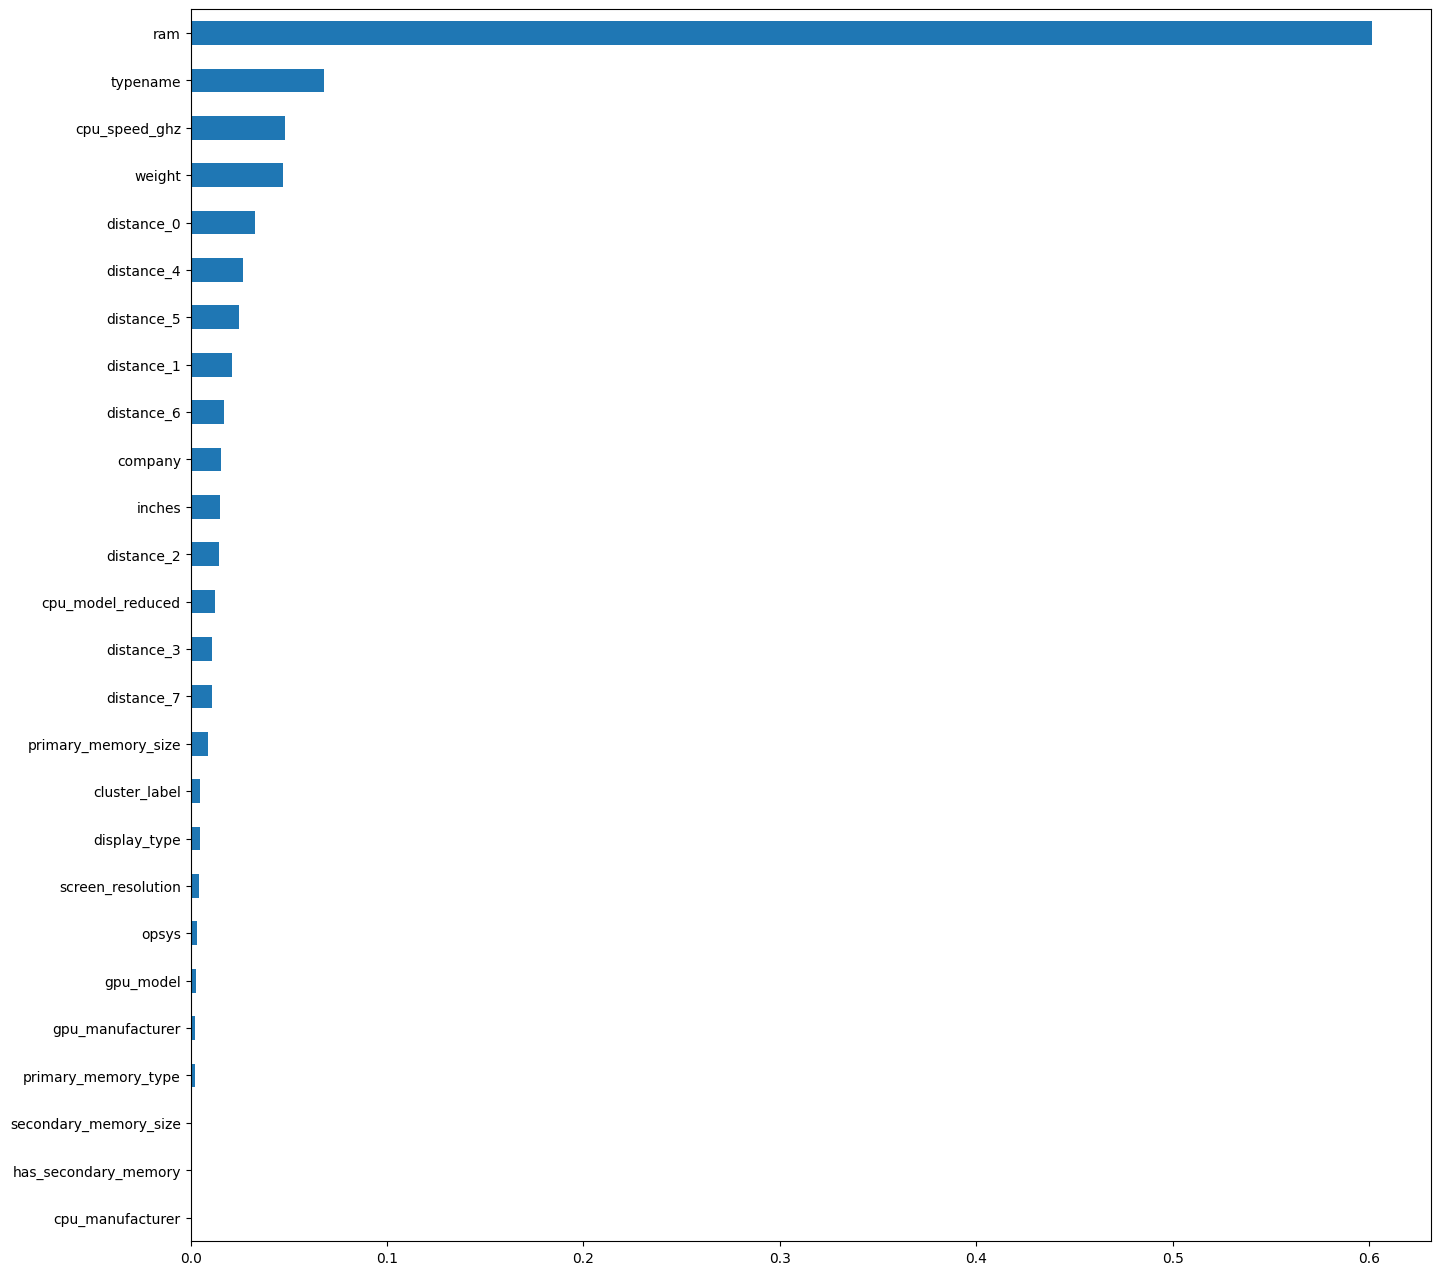

In [149]:
feat_importance = pd.Series(
    rf_pipeline[-1].feature_importances_, index=rf_pipeline[-2].get_feature_names_out()
).sort_values()
feat_importance.plot(kind="barh", figsize=(16, 16))

### Find optimal number of clusters

In [163]:
param_grid = {"featureunion__kmeans_feat__customkmeans__n_clusters": [2, 4, 6, 8, 10]}

grid_search = GridSearchCV(
    rf_pipeline, param_grid=param_grid, scoring="neg_root_mean_squared_error", n_jobs=-1
)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'featureunion__kmeans_f...ustomkmeans__n_clusters': [2, 4, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformer_list,"[('base_feat', ...), ('kmeans_feat', ...)]"


In [164]:
result = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")

In [165]:
result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_featureunion__kmeans_feat__customkmeans__n_clusters,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.411360,0.540558,0.087377,0.051438,2,{'featureunion__kmeans_feat__customkmeans__n_c...,-311.515828,-287.995371,-295.219963,-396.862471,-324.094152,-323.137557,38.950502,1
1,1.424408,0.239217,0.106696,0.028858,4,{'featureunion__kmeans_feat__customkmeans__n_c...,-303.967588,-290.079308,-299.141188,-408.493220,-318.591898,-324.054640,43.216220,2
2,1.765986,0.351683,0.072988,0.034608,6,{'featureunion__kmeans_feat__customkmeans__n_c...,-306.883109,-289.143143,-296.347533,-411.461957,-324.658214,-325.698791,44.515717,3
4,2.356979,0.405091,0.058045,0.012334,10,{'featureunion__kmeans_feat__customkmeans__n_c...,-305.049099,-283.270547,-302.697196,-413.119589,-335.646740,-327.956634,45.763539,4
3,1.999334,0.322785,0.088335,0.043836,8,{'featureunion__kmeans_feat__customkmeans__n_c...,-313.638820,-286.025952,-298.492554,-421.828476,-330.036774,-330.004515,48.221560,5


In [167]:
# Get test set predictions
rf_grid_test_pred = grid_search.predict(X_test)
rf_grid_test_rmse = rmse(y_test, rf_test_pred)

print("RF Model Test Error:", rf_test_rmse)

RF Model Test Error: 315.64723705941935


<Axes: >

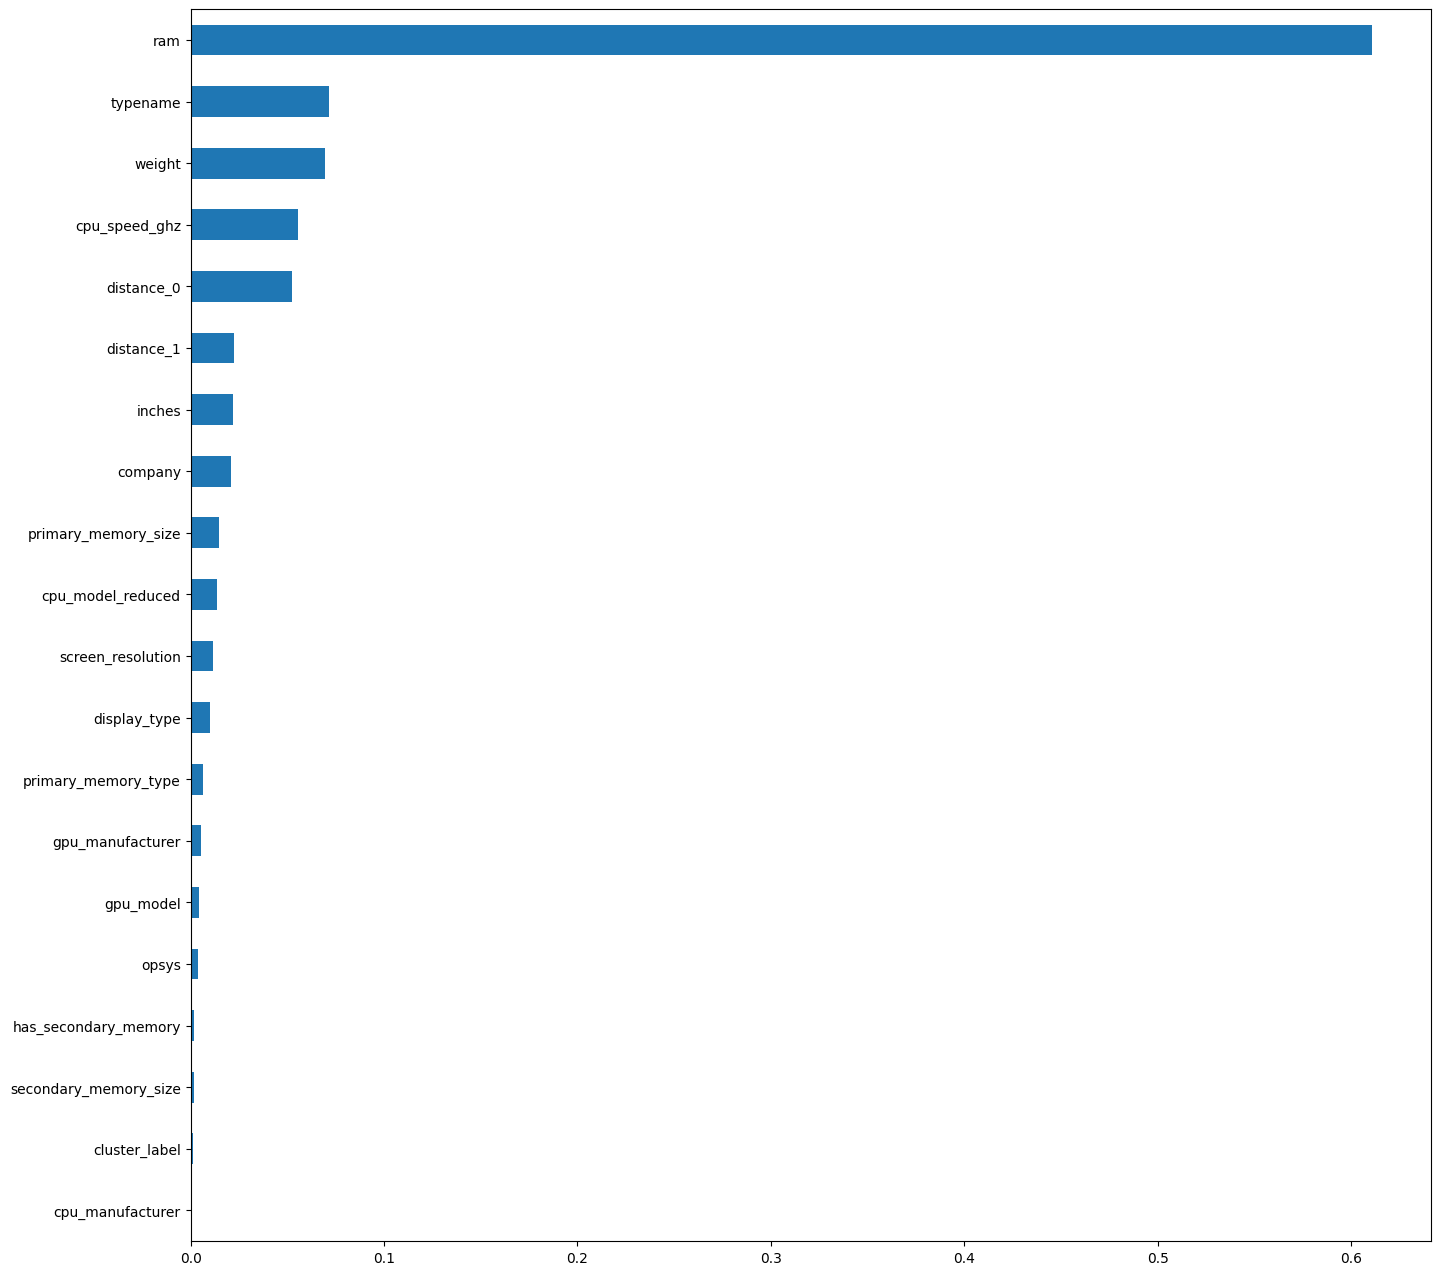

In [168]:
rf_grid_feat_importance = pd.Series(
    grid_search.best_estimator_[-1].feature_importances_, index=grid_search.best_estimator_[-2].get_feature_names_out()
).sort_values()
rf_grid_feat_importance.plot(kind="barh", figsize=(16, 16))